In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import anndata
import scanpy as sc
import pybiomart
import scvi
import torch
import random
import seaborn as sns

In [2]:
cwd = os.getcwd()
cwd

'/home/merlin/Documents/Programming/FigureOneLab/trevino'

In [3]:
# Load metadata into pandas dataframe
meta = pd.read_csv(cwd+'/data/GSE162170_rna_cell_metadata.txt.gz', compression='gzip', sep='\t')
meta.index = meta['Cell.ID']  # Cell ID's as row names
meta.index.name = None  # Clean up index names

In [4]:
print(meta.head())

                                                       Cell.ID      Sample.ID  \
hft_w20_p3_r1_AAACCCAAGCTGCGAA  hft_w20_p3_r1_AAACCCAAGCTGCGAA  hft_w20_p3_r1   
hft_w20_p3_r1_AAACCCAAGGTAGTAT  hft_w20_p3_r1_AAACCCAAGGTAGTAT  hft_w20_p3_r1   
hft_w20_p3_r1_AAACCCACAACTCCAA  hft_w20_p3_r1_AAACCCACAACTCCAA  hft_w20_p3_r1   
hft_w20_p3_r1_AAACCCACATAGTCAC  hft_w20_p3_r1_AAACCCACATAGTCAC  hft_w20_p3_r1   
hft_w20_p3_r1_AAACCCAGTACAGGTG  hft_w20_p3_r1_AAACCCAGTACAGGTG  hft_w20_p3_r1   

                                  Age Tissue.ID Sample.Type   Assay     Batch  \
hft_w20_p3_r1_AAACCCAAGCTGCGAA  pcw20      HFT3         HFT  RNA v3  b2019_06   
hft_w20_p3_r1_AAACCCAAGGTAGTAT  pcw20      HFT3         HFT  RNA v3  b2019_06   
hft_w20_p3_r1_AAACCCACAACTCCAA  pcw20      HFT3         HFT  RNA v3  b2019_06   
hft_w20_p3_r1_AAACCCACATAGTCAC  pcw20      HFT3         HFT  RNA v3  b2019_06   
hft_w20_p3_r1_AAACCCAGTACAGGTG  pcw20      HFT3         HFT  RNA v3  b2019_06   

                          

In [5]:
%%time
# Old approach was causing OOM issues due to large file size and duplication in transpose function
# counts = pd.read_csv(cwd+'/data/GSE162170_rna_counts.tsv.gz', compression='gzip', sep='\t')
# counts = counts.transpose()
# counts

# Using built in scanpy function directly
adata = sc.read_csv(cwd+'/data/GSE162170_rna_counts.tsv.gz', delimiter='\t')

CPU times: user 1min 16s, sys: 3.58 s, total: 1min 19s
Wall time: 1min 19s


In [6]:
adata = adata.transpose()

In [7]:
np.random.seed(42)
n_dev_cells = 1000
dev_cell_indices = np.random.choice(adata.n_obs, size=n_dev_cells, replace = False)

# Subset the data for development
# Specific row indices and every column
# .copy() creates a deep copy that is a separate object that can be further used
adata_dev = adata[dev_cell_indices, :].copy()

In [8]:
%%time
# adata = anndata.AnnData(X=counts,
#                         obs=meta,
#                         var=counts.columns.to_frame())

adata_dev.obs = meta.loc[adata_dev.obs.index]  # Align by cell ID
adata_dev

CPU times: user 6.94 ms, sys: 66 µs, total: 7 ms
Wall time: 8.73 ms


AnnData object with n_obs × n_vars = 1000 × 33355
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features'

In [9]:
print(f"Development subset: {adata_dev.n_obs} cells, {adata_dev.n_vars}")
print(adata_dev.var.head())

Development subset: 1000 cells, 33355
Empty DataFrame
Columns: []
Index: [ENSG00000243485, ENSG00000237613, ENSG00000186092, ENSG00000238009, ENSG00000239945]


In [10]:
%%time
# Dataframe with columns ensembl_gene_id and hgnc_symbol
a = sc.queries.biomart_annotations('hsapiens', ['ensembl_gene_id','hgnc_symbol'])

# Creates dict where key is ensembl_gene_id and value is hgnc_symbol
b = dict(zip(a['ensembl_gene_id'], a['hgnc_symbol']))

# Creates hgnc_symbol column with mapped ensemble_gene_id -> hgnc_symbols
adata_dev.var['hgnc_symbol'] = adata_dev.var.index.map(b)

# Replaces current index with newly created hgnc_symbol column
adata_dev.var.index = adata_dev.var['hgnc_symbol']

# Removes index name and removes the temporary hgnc_column
adata_dev.var.index.name = None
adata_dev.var.drop(columns=['hgnc_symbol'], inplace=True)
adata_dev.var

CPU times: user 396 ms, sys: 32.9 ms, total: 429 ms
Wall time: 7.88 s


""
MIR1302-2HG
FAM138A
OR4F5
NaN
NaN
...
MT-ND4L
MT-ND4
MT-ND5
MT-ND6


In [11]:
adata_dev.var_names_make_unique

<bound method AnnData.var_names_make_unique of AnnData object with n_obs × n_vars = 1000 × 33355
    obs: 'Cell.ID', 'Sample.ID', 'Age', 'Tissue.ID', 'Sample.Type', 'Assay', 'Batch', 'seurat_clusters', 'RNA.Counts', 'RNA.Features', 'Percent.MT', 'Percent.Ribo', 'Cell.Barcode', 'DF_pANN', 'DF_classification', 'DF_pANN_quantile', 'Spliced.Counts', 'Spliced.Features', 'Unspliced.Counts', 'Unspliced.Features', 'Ambiguous.Counts', 'Ambiguous.Features'>

In [12]:
a = ~adata_dev.var.index.isnull()
# Also OOM error while running due to duplicate creation
# adata = adata[:,a].copy()
# Instead subset using direct approach to reduce memory usage

adata_dev = adata_dev[:, a].copy()

/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [13]:
adata_dev.var

""
MIR1302-2HG
FAM138A
OR4F5
OR4F29
OR4F16
...
MT-ND4L
MT-ND4
MT-ND5
MT-ND6


In [14]:
%%time
# Removes genes that are expressed in less than 10 cells
sc.pp.filter_genes(adata_dev, min_cells=10)

# Removes cells that have less than 200 expressed genes
sc.pp.filter_cells(adata_dev, min_genes=200)

CPU times: user 73.3 ms, sys: 40 µs, total: 73.3 ms
Wall time: 72 ms


In [15]:
#sc.pp.subsample(adata, n_obs=40000, random_state=0, copy=False)

In [16]:
%%time
adata_dev.X = scipy.sparse.csr_matrix(adata_dev.X.copy())
adata_dev.layers['counts'] = scipy.sparse.csr_matrix(adata_dev.X.copy())
#adata.layers['log2_counts'] = sc.pp.log1p(adata.layers['counts'].copy(), base=2)

CPU times: user 106 ms, sys: 38 µs, total: 106 ms
Wall time: 106 ms


In [17]:
%%time
random.seed(17)
scvi.model.SCVI.setup_anndata(adata_dev, layer='counts', batch_key='Sample.ID')
scvi_model = scvi.model.SCVI(adata_dev, n_layers=2, n_latent=30, n_hidden=128, gene_likelihood='nb')
scvi_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/merlin/miniconda3/envs/figure-one-lab/lib/python3.9/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 400/400: 100%|██████████| 400/400 [02:56<00:00,  2.27it/s, v_num=1, train_loss_step=8.24e+3, train_loss_epoch=5.81e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [02:56<00:00,  2.26it/s, v_num=1, train_loss_step=8.24e+3, train_loss_epoch=5.81e+3]
CPU times: user 23min 13s, sys: 9.69 s, total: 23min 23s
Wall time: 2min 57s


In [18]:
%%time
random.seed(17)
adata_dev.obsm['X_scvi'] = scvi_model.get_latent_representation()
adata_dev.layers['counts_scvi'] = scvi_model.get_normalized_expression(library_size=10000)
#adata.layers['log2_counts_scvi'] = sc.pp.log1p(adata.layers['counts_scvi'].copy(), base=2)

CPU times: user 1.08 s, sys: 4.96 ms, total: 1.08 s
Wall time: 140 ms


<timed exec>:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


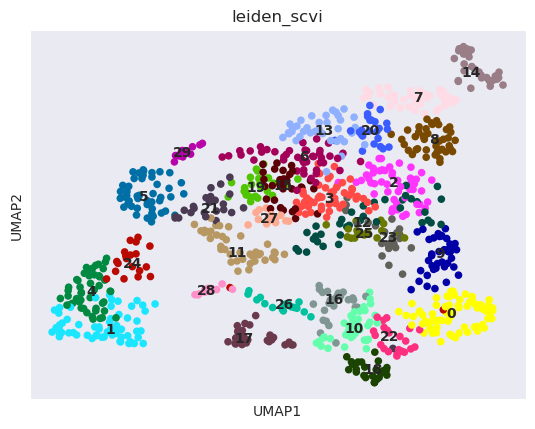

CPU times: user 6.83 s, sys: 1.56 s, total: 8.39 s
Wall time: 5.07 s


In [19]:
%%time
sc.pp.neighbors(adata_dev, use_rep='X_scvi', key_added='neighbors_scvi', n_neighbors=20)
sc.tl.leiden(adata_dev, neighbors_key='neighbors_scvi', key_added='leiden_scvi', resolution=3)
sc.tl.umap(adata_dev, neighbors_key='neighbors_scvi')
sc.pl.umap(adata_dev, color=['leiden_scvi'], legend_loc='on data')

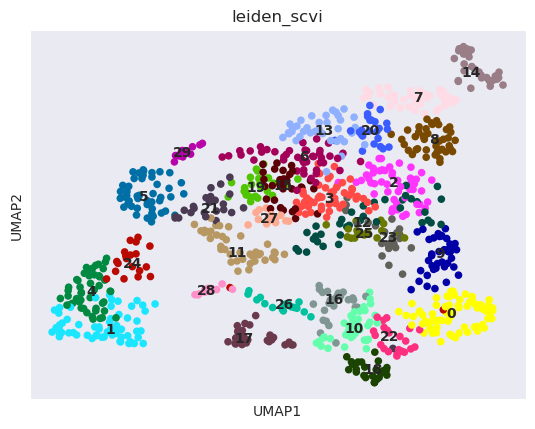

CPU times: user 2.14 s, sys: 94.9 ms, total: 2.24 s
Wall time: 735 ms


In [20]:
%%time
sc.pp.neighbors(adata_dev, use_rep='X_scvi', key_added='neighbors_scvi', n_neighbors=20)
sc.tl.leiden(adata_dev, neighbors_key='neighbors_scvi', key_added='leiden_scvi', resolution=3)
sc.tl.umap(adata_dev, neighbors_key='neighbors_scvi')
sc.pl.umap(adata_dev, color=['leiden_scvi'], legend_loc='on data')

In [21]:
%%time
adata_dev.write(cwd+'/outs/231226_trevino_rna_scvi.h5ad')

CPU times: user 68.7 ms, sys: 177 ms, total: 246 ms
Wall time: 92.9 ms
